# XGBoost One-Week Daily Attendance Forecast — PortAventura World

**Objective:** Forecast daily attendance for **July 26 – August 1, 2022** (7 days) using an XGBoost regressor trained on historical daily data with calendar, weather, COVID, lag, and rolling features.

**Approach:** Recursive one-step-ahead forecasting — each predicted day is appended to history before computing features for the next day.

In [10]:
# ============================================================
# CELL 1 — IMPORTS & DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# --- Resolve data directory ---
if os.path.exists('final_data/attendance.csv'):
    DATA_DIR = 'final_data'
elif os.path.exists('../final_data/attendance.csv'):
    DATA_DIR = '../final_data'
else:
    raise FileNotFoundError("Cannot find final_data directory")

# --- Load attendance (PortAventura World only) ---
att = pd.read_csv(f'{DATA_DIR}/attendance.csv')
att['USAGE_DATE'] = pd.to_datetime(att['USAGE_DATE'])

pa = att[att['FACILITY_NAME'] == 'PortAventura World'].copy()
pa = pa.rename(columns={'USAGE_DATE': 'date', 'attendance': 'y'})
pa = pa[['date', 'y']].sort_values('date').reset_index(drop=True)

print(f"PortAventura daily attendance: {len(pa)} rows")
print(f"Date range: {pa['date'].min().date()} → {pa['date'].max().date()}")

# --- Load pre-aggregated daily weather ---
weather = pd.read_csv(f'{DATA_DIR}/merged/merged_weather_waiting_daily.csv')
weather['date'] = pd.to_datetime(weather['date'])

# Keep only the weather columns we need
weather_cols_keep = [
    'date', 'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
    'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
    'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total',
    'has_rain', 'has_snow'
]
weather = weather[weather_cols_keep]

print(f"\nWeather daily: {len(weather)} rows")
print(f"Date range: {weather['date'].min().date()} → {weather['date'].max().date()}")

pa.head()

PortAventura daily attendance: 1182 rows
Date range: 2018-06-01 → 2022-07-26

Weather daily: 1691 rows
Date range: 2018-01-01 → 2022-08-18


,date,y
0,2018-06-01,46804
1,2018-06-02,57940
2,2018-06-03,44365
3,2018-06-04,37617
4,2018-06-05,32438


In [11]:
# ============================================================
# CELL 2 — FEATURE ENGINEERING
# ============================================================

# --- Merge attendance + weather ---
df = pa.merge(weather, on='date', how='left')
print(f"Merged dataset: {len(df)} rows, {df.shape[1]} columns")
print(f"Missing weather rows: {df['temp_mean'].isna().sum()}")

# --- Clean negative attendance via interpolation ---
neg_mask = df['y'] < 0
print(f"Replacing {neg_mask.sum()} negative attendance values via interpolation")
df.loc[neg_mask, 'y'] = np.nan
df['y'] = df['y'].interpolate(method='linear')

# --- Calendar features ---
df['day_of_week'] = df['date'].dt.dayofweek          # 0=Mon, 6=Sun
df['month']       = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['year']        = df['date'].dt.year
df['is_summer']   = df['month'].isin([6, 7, 8]).astype(int)
df['is_holiday_season'] = df['month'].isin([6, 7, 8, 12]).astype(int)

# Cyclical encodings
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- COVID features ---
covid_start = pd.Timestamp('2020-02-01')
covid_end   = pd.Timestamp('2021-06-30')
df['is_covid']    = ((df['date'] >= covid_start) & (df['date'] <= covid_end)).astype(int)
df['is_recovery'] = (df['date'] > covid_end).astype(int)
df['recovery_months'] = np.where(
    df['date'] > covid_end,
    ((df['date'] - covid_end).dt.days / 30.44).clip(upper=12),
    0.0
)

# --- Forward-fill any missing weather ---
weather_num_cols = ['temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
                    'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
                    'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total']
df[weather_num_cols] = df[weather_num_cols].ffill().bfill()
df['has_rain'] = (df['rain_total'] > 0).astype(int)
df['has_snow'] = (df['snow_total'] > 0).astype(int)

# --- Lag features (shift from original y) ---
df = df.set_index('date').sort_index()
for lag in [7, 14, 28, 365]:
    df[f'lag_{lag}'] = df['y'].shift(lag)

# --- Rolling statistics (shifted by 1 to avoid leakage) ---
for window in [7, 14, 30]:
    df[f'roll_mean_{window}'] = df['y'].shift(1).rolling(window).mean()
    df[f'roll_std_{window}']  = df['y'].shift(1).rolling(window).std()

print(f"\nFinal dataset (before NaN drop): {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"NaN rows (from lagging): {df.isna().any(axis=1).sum()}")

# Define feature columns (used throughout)
FEATURE_COLS = [
    # Calendar
    'day_of_week', 'month', 'week_of_year', 'day_of_year', 'is_weekend', 'year',
    'is_summer', 'is_holiday_season',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Weather
    'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
    'humidity_mean', 'wind_speed_mean', 'pressure_mean', 'clouds_mean',
    'rain_total', 'has_rain',
    # COVID
    'is_covid', 'is_recovery', 'recovery_months',
    # Lags & rolling
    'lag_7', 'lag_14', 'lag_28', 'lag_365',
    'roll_mean_7', 'roll_mean_14', 'roll_mean_30',
    'roll_std_7', 'roll_std_14', 'roll_std_30',
]

print(f"\nFeature columns: {len(FEATURE_COLS)}")
df.tail(3)

Merged dataset: 1182 rows, 15 columns
Missing weather rows: 0
Replacing 37 negative attendance values via interpolation

Final dataset (before NaN drop): (1182, 39)
Date range: 2018-06-01 → 2022-07-26
NaN rows (from lagging): 365

Feature columns: 35


,y,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,clouds_mean,...,lag_7,lag_14,lag_28,lag_365,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,roll_std_30
date,,,,,,,,,,,,,,,,,,,,,
2022-07-24,45261.0,24.897917,16.07,32.56,25.453333,68.333333,2.233750,2.92,1016.666667,26.666667,...,40938.0,42301.0,45930.0,20507.0,47728.142857,4000.545189,48082.857143,3631.617183,46673.933333,3894.031666
2022-07-25,53764.0,22.689583,17.51,26.85,22.826667,67.791667,4.442917,6.91,1013.541667,60.583333,...,46808.0,46846.0,47382.0,17566.0,48345.714286,2981.531022,48294.285714,3343.875468,46476.700000,3806.907199
2022-07-26,26391.0,19.101667,15.92,22.48,19.017917,74.666667,3.003750,4.06,1018.750000,76.500000,...,46753.0,53867.0,48350.0,15573.0,49339.428571,3498.050450,48788.428571,3613.663211,46777.900000,4015.525373


In [12]:
# ============================================================
# CELL 3 — TRAIN / TEST SPLIT
# ============================================================

CUTOFF = pd.Timestamp('2022-07-25')   # last day of training data
FORECAST_START = pd.Timestamp('2022-07-26')
FORECAST_END   = pd.Timestamp('2022-08-23')
FORECAST_DAYS  = 29

# Training set: all data up to (and including) July 25
# Drop NaN rows caused by lag_365 (first ~365 days)
train_df = df.loc[:CUTOFF].dropna(subset=FEATURE_COLS).copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df['y']

# Validation split for early stopping: last 60 days of training
VAL_DAYS = 60
val_cutoff = CUTOFF - pd.Timedelta(days=VAL_DAYS)
X_tr  = X_train.loc[:val_cutoff]
y_tr  = y_train.loc[:val_cutoff]
X_val = X_train.loc[val_cutoff + pd.Timedelta(days=1):]
y_val = y_train.loc[val_cutoff + pd.Timedelta(days=1):]

print(f"Training set:    {len(X_train)} rows  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"  ├─ Fit split:  {len(X_tr)} rows")
print(f"  └─ Val split:  {len(X_val)} rows  (last {VAL_DAYS} days for early stopping)")
print(f"\nForecast window: {FORECAST_START.date()} → {FORECAST_END.date()} ({FORECAST_DAYS} days)")

# Actual value for July 26 (the one day we can validate)
actual_jul26 = df.loc[FORECAST_START, 'y'] if FORECAST_START in df.index else None
print(f"Actual attendance on July 26: {actual_jul26:,.0f}" if actual_jul26 else "July 26 actual not available")

Training set:    816 rows  (2019-06-01 → 2022-07-25)
  ├─ Fit split:  756 rows
  └─ Val split:  60 rows  (last 60 days for early stopping)

Forecast window: 2022-07-26 → 2022-08-23 (29 days)
Actual attendance on July 26: 26,391


Best iteration: 71
Best validation score (RMSE): 5052

Training residual std: 2,780
Training MAE: 1,978
Training MAPE: 272.45%


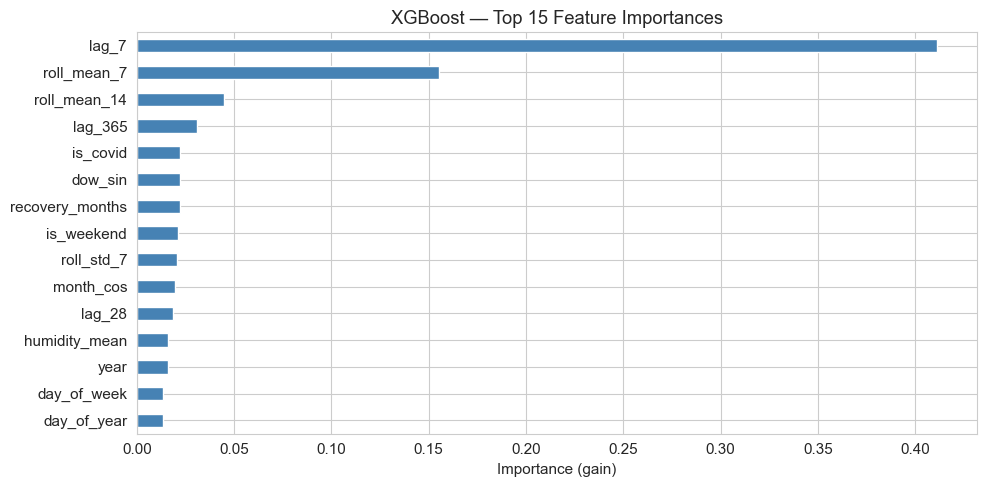

In [13]:
# ============================================================
# CELL 4 — TRAIN XGBOOST MODEL
# ============================================================

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best validation score (RMSE): {model.best_score:.0f}")

# --- Training residuals (for confidence band later) ---
train_pred = model.predict(X_train)
train_residuals = y_train.values - train_pred
residual_std = np.std(train_residuals)
print(f"\nTraining residual std: {residual_std:,.0f}")
print(f"Training MAE: {mean_absolute_error(y_train, train_pred):,.0f}")
print(f"Training MAPE: {np.mean(np.abs(train_residuals) / y_train.values) * 100:.2f}%")

# --- Feature importance (top 15) ---
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 15 Feature Importances')
ax.set_xlabel('Importance (gain)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 5 — RECURSIVE ONE-STEP-AHEAD FORECASTING
# ============================================================

# Build a weather lookup for the forecast period
weather_indexed = weather.set_index('date')

# Working copy of attendance history (will be extended with predictions)
history = df.loc[:CUTOFF, 'y'].copy()

forecast_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
predictions = []

for fdate in forecast_dates:
    # --- Calendar features ---
    row = {}
    row['day_of_week'] = fdate.dayofweek
    row['month']       = fdate.month
    row['week_of_year'] = fdate.isocalendar().week
    row['day_of_year'] = fdate.dayofyear
    row['is_weekend']  = int(fdate.dayofweek >= 5)
    row['year']        = fdate.year
    row['is_summer']   = int(fdate.month in [6, 7, 8])
    row['is_holiday_season'] = int(fdate.month in [6, 7, 8, 12])
    row['dow_sin']   = np.sin(2 * np.pi * fdate.dayofweek / 7)
    row['dow_cos']   = np.cos(2 * np.pi * fdate.dayofweek / 7)
    row['month_sin'] = np.sin(2 * np.pi * fdate.month / 12)
    row['month_cos'] = np.cos(2 * np.pi * fdate.month / 12)

    # --- Weather features (actual weather for the forecast dates) ---
    if fdate in weather_indexed.index:
        w = weather_indexed.loc[fdate]
        row['temp_mean']       = w['temp_mean']
        row['temp_min']        = w['temp_min']
        row['temp_max']        = w['temp_max']
        row['feels_like_mean'] = w['feels_like_mean']
        row['humidity_mean']   = w['humidity_mean']
        row['wind_speed_mean'] = w['wind_speed_mean']
        row['pressure_mean']   = w['pressure_mean']
        row['clouds_mean']     = w['clouds_mean']
        row['rain_total']      = w['rain_total']
        row['has_rain']        = int(w['rain_total'] > 0)
    else:
        # Fallback: use last known weather
        last_w = weather_indexed.iloc[-1]
        for c in ['temp_mean','temp_min','temp_max','feels_like_mean',
                   'humidity_mean','wind_speed_mean','pressure_mean',
                   'clouds_mean','rain_total']:
            row[c] = last_w[c]
        row['has_rain'] = int(last_w['rain_total'] > 0)

    # --- COVID features ---
    row['is_covid']    = int(covid_start <= fdate <= covid_end)
    row['is_recovery'] = int(fdate > covid_end)
    row['recovery_months'] = min(((fdate - covid_end).days / 30.44), 12) if fdate > covid_end else 0.0

    # --- Lag features (always reference known/predicted history) ---
    for lag in [7, 14, 28, 365]:
        lag_date = fdate - pd.Timedelta(days=lag)
        row[f'lag_{lag}'] = history.get(lag_date, np.nan)

    # --- Rolling features (from shifted history, i.e., up to yesterday) ---
    yesterday = fdate - pd.Timedelta(days=1)
    recent = history.loc[:yesterday]
    row['roll_mean_7']  = recent.iloc[-7:].mean()  if len(recent) >= 7  else recent.mean()
    row['roll_mean_14'] = recent.iloc[-14:].mean() if len(recent) >= 14 else recent.mean()
    row['roll_mean_30'] = recent.iloc[-30:].mean() if len(recent) >= 30 else recent.mean()
    row['roll_std_7']   = recent.iloc[-7:].std()   if len(recent) >= 7  else recent.std()
    row['roll_std_14']  = recent.iloc[-14:].std()   if len(recent) >= 14 else recent.std()
    row['roll_std_30']  = recent.iloc[-30:].std()   if len(recent) >= 30 else recent.std()

    # --- Predict ---
    X_forecast = pd.DataFrame([row])[FEATURE_COLS]
    pred = float(np.clip(model.predict(X_forecast), 0, None)[0])

    predictions.append({'date': fdate, 'predicted': pred})

    # Append prediction to history for next iteration's lags / rolling
    history.loc[fdate] = pred

# Collect results
forecast_df = pd.DataFrame(predictions)
forecast_df['day_name'] = forecast_df['date'].dt.day_name()

print("Recursive one-step-ahead forecast complete!")
print(f"Forecast period: {forecast_df['date'].iloc[0].date()} → {forecast_df['date'].iloc[-1].date()}")
forecast_df

Recursive one-step-ahead forecast complete!
Forecast period: 2022-07-26 → 2022-08-23


,date,predicted,day_name
0,2022-07-26,45168.464844,Tuesday
1,2022-07-27,44844.699219,Wednesday
2,2022-07-28,44950.613281,Thursday
3,2022-07-29,44329.453125,Friday
4,2022-07-30,52459.949219,Saturday
5,2022-07-31,45359.386719,Sunday
6,2022-08-01,44423.214844,Monday
7,2022-08-02,43053.878906,Tuesday
8,2022-08-03,42342.273438,Wednesday
9,2022-08-04,41658.625000,Thursday


In [15]:
# ============================================================
# CELL 6 — RESULTS & EVALUATION
# ============================================================

# Add confidence band (±1.96 * training residual std ≈ 95% interval)
forecast_df['lower'] = (forecast_df['predicted'] - 1.96 * residual_std).clip(lower=0)
forecast_df['upper'] = forecast_df['predicted'] + 1.96 * residual_std

# Print nicely formatted table
print("=" * 75)
print("  XGBoost 7-Day Forecast — PortAventura World")
print("=" * 75)
print(f"  {'Date':<14} {'Day':<12} {'Predicted':>12}   {'95% CI Lower':>12}   {'95% CI Upper':>12}")
print("-" * 75)
for _, r in forecast_df.iterrows():
    print(f"  {r['date'].strftime('%Y-%m-%d'):<14} {r['day_name']:<12} {r['predicted']:>12,.0f}   {r['lower']:>12,.0f}   {r['upper']:>12,.0f}")
print("=" * 75)
print(f"  Weekly total:  {forecast_df['predicted'].sum():>12,.0f}")
print(f"  Daily average: {forecast_df['predicted'].mean():>12,.0f}")

# --- Evaluation on July 26 (the one day with actual data) ---
if actual_jul26 is not None:
    pred_jul26 = forecast_df.loc[forecast_df['date'] == FORECAST_START, 'predicted'].values[0]
    error = actual_jul26 - pred_jul26
    mape_jul26 = abs(error) / actual_jul26 * 100
    print(f"\n--- Validation on July 26, 2022 ---")
    print(f"  Actual:    {actual_jul26:>10,.0f}")
    print(f"  Predicted: {pred_jul26:>10,.0f}")
    print(f"  Error:     {error:>+10,.0f}")
    print(f"  MAPE:      {mape_jul26:>9.2f}%")

  XGBoost 7-Day Forecast — PortAventura World
  Date           Day             Predicted   95% CI Lower   95% CI Upper
---------------------------------------------------------------------------
  2022-07-26     Tuesday            45,168         39,719         50,618
  2022-07-27     Wednesday          44,845         39,395         50,294
  2022-07-28     Thursday           44,951         39,501         50,400
  2022-07-29     Friday             44,329         38,880         49,779
  2022-07-30     Saturday           52,460         47,011         57,909
  2022-07-31     Sunday             45,359         39,910         50,809
  2022-08-01     Monday             44,423         38,974         49,873
  2022-08-02     Tuesday            43,054         37,604         48,503
  2022-08-03     Wednesday          42,342         36,893         47,792
  2022-08-04     Thursday           41,659         36,209         47,108
  2022-08-05     Friday             45,790         40,341         51,239
  

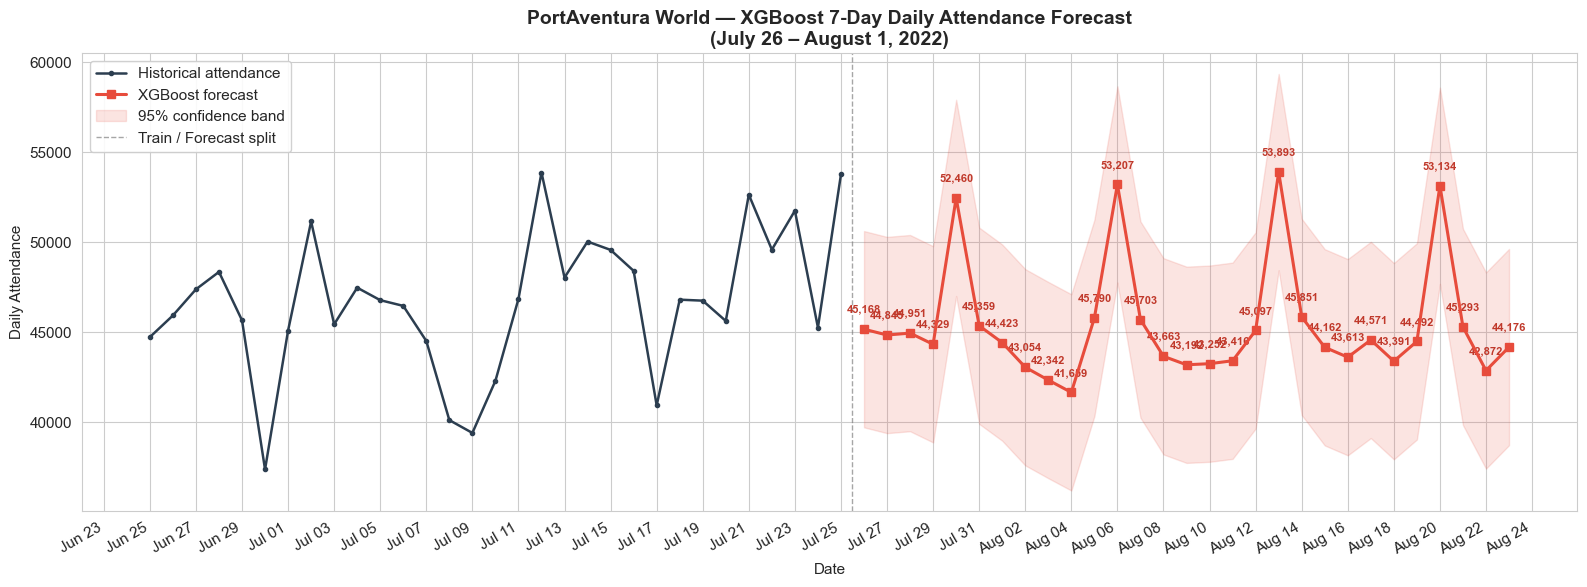

In [16]:
# ============================================================
# CELL 7 — VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

# --- Recent historical attendance (last 30 days before forecast) ---
history_window = df.loc[CUTOFF - pd.Timedelta(days=30):CUTOFF, 'y']
ax.plot(history_window.index, history_window.values,
        color='#2c3e50', linewidth=1.8, marker='o', markersize=3,
        label='Historical attendance', zorder=3)

# --- Forecast ---
ax.plot(forecast_df['date'], forecast_df['predicted'],
        color='#e74c3c', linewidth=2.2, marker='s', markersize=6,
        label='XGBoost forecast', zorder=4)
ax.fill_between(forecast_df['date'],
                forecast_df['lower'], forecast_df['upper'],
                color='#e74c3c', alpha=0.15, label='95% confidence band', zorder=1)



# --- Vertical line at cutoff ---
ax.axvline(CUTOFF + pd.Timedelta(hours=12), color='grey',
           linestyle='--', linewidth=1, alpha=0.7, label='Train / Forecast split')

# --- Formatting ---
ax.set_title('PortAventura World — XGBoost 4-Weeks Daily Attendance Forecast\n'
             '(July 26 – August 24, 2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Attendance')
ax.legend(loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig.autofmt_xdate(rotation=30)

# Add value labels on forecast points
for _, r in forecast_df.iterrows():
    ax.annotate(f"{r['predicted']:,.0f}",
                xy=(r['date'], r['predicted']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
os.makedirs(f'{DATA_DIR}/forecasts/daily', exist_ok=True)
forecast_df[['date', 'day_name', 'predicted', 'lower', 'upper']].to_csv(
    f'{DATA_DIR}/forecasts/daily/xgboost_daily_oneweek.csv', index=False
)